# NFL Data Analysis Example

This notebook shows how to connect to the NFL database and perform basic analysis.

In [100]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [101]:
# Connect to the NFL database
db_path = Path('../data/nfl.duckdb')
conn = duckdb.connect(str(db_path))

print(f"Connected to database: {db_path}")
print("Database connection established successfully!")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

Connected to database: ../data/nfl.duckdb
Database connection established successfully!


In [102]:
df=pd.read_sql_query("select * from pbp where season=2025",conn)

/var/folders/kp/8st1tbqj0px8gr_28_46kn4m0000gn/T/ipykernel_70977/2288837903.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query("select * from pbp where season=2025",conn)


In [103]:
df['def_epa']=df['epa']*-1

In [104]:
offense_epa=df.groupby(['posteam','season','game_id','defteam']).agg({'epa':'sum'})
offense_epa.reset_index(inplace=True)
offense_epa.rename(columns={'epa':'offense_epa','posteam':'team','defteam':'opponent'},inplace=True)


defense_epa=df.groupby(['defteam','season','game_id']).agg({'def_epa':'sum'})
defense_epa.reset_index(inplace=True)
defense_epa.rename(columns={'def_epa':'defense_epa','defteam':'team'},inplace=True)

epa_game_totals = offense_epa.merge(defense_epa,on=['team','season','game_id'],how='outer')


team_averages = epa_game_totals\
    .groupby(['team'
            ,'season'])\
        .agg(opp_off_epapg= ('offense_epa','mean')
                ,opp_off_epa_median= ('offense_epa','median')
                ,opp_off_epa_25= ('offense_epa',lambda x: x.quantile(0.25))
                ,opp_off_epa_75= ('offense_epa',lambda x: x.quantile(0.75))
                ,opp_off_epa_max= ('offense_epa','max')
                ,opp_off_epa_min=('offense_epa','min')
                #defense
                ,opp_def_epapg= ('defense_epa','mean')
                ,opp_def_epa_median= ('defense_epa','median')
                ,opp_def_epa_25= ('defense_epa',lambda x: x.quantile(0.25))
                ,opp_def_epa_75= ('defense_epa',lambda x: x.quantile(0.75))
                ,opp_def_epa_max= ('defense_epa','max')
                ,opp_def_epa_min=('defense_epa','min'))\
            .reset_index() 


In [105]:
team_averages.head()

,team,season,opp_off_epapg,opp_off_epa_median,opp_off_epa_25,opp_off_epa_75,opp_off_epa_max,opp_off_epa_min,opp_def_epapg,opp_def_epa_median,opp_def_epa_25,opp_def_epa_75,opp_def_epa_max,opp_def_epa_min
0,ARI,2025,-1.737061,-0.228287,-5.520431,1.298027,10.565547,-17.957624,-7.520094,-8.711832,-17.651174,1.722162,9.797154,-28.006589
1,ATL,2025,-1.377999,0.979706,-5.959522,4.644943,17.361648,-30.302195,-1.894489,-4.839261,-11.772667,4.125293,23.977998,-16.837040
2,BAL,2025,3.422156,5.993974,-3.042854,9.729052,26.763928,-23.410582,-2.199921,-5.359490,-14.480463,13.464724,22.393453,-26.565999
3,BUF,2025,9.660041,11.890339,-0.099781,19.531310,23.036675,-7.331914,-1.733462,-4.644943,-13.196517,5.965946,18.490458,-24.160796
4,CAR,2025,-1.365807,-0.590470,-9.526280,9.779063,13.580872,-25.359635,-3.586531,-4.182996,-9.519920,0.033890,30.302195,-22.319240


In [106]:
epa_game_totals.head()


,team,season,game_id,opponent,offense_epa,defense_epa
0,ARI,2025,2025_01_ARI_NO,NO,1.298027,8.639995
1,ARI,2025,2025_02_CAR_ARI,CAR,2.853655,0.590470
2,ARI,2025,2025_03_ARI_SF,SF,-0.228287,1.722162
3,ARI,2025,2025_04_SEA_ARI,SEA,-0.490411,-4.971264
4,ARI,2025,2025_05_TEN_ARI,TEN,-5.520431,2.101735


In [107]:
team_averages.head()

,team,season,opp_off_epapg,opp_off_epa_median,opp_off_epa_25,opp_off_epa_75,opp_off_epa_max,opp_off_epa_min,opp_def_epapg,opp_def_epa_median,opp_def_epa_25,opp_def_epa_75,opp_def_epa_max,opp_def_epa_min
0,ARI,2025,-1.737061,-0.228287,-5.520431,1.298027,10.565547,-17.957624,-7.520094,-8.711832,-17.651174,1.722162,9.797154,-28.006589
1,ATL,2025,-1.377999,0.979706,-5.959522,4.644943,17.361648,-30.302195,-1.894489,-4.839261,-11.772667,4.125293,23.977998,-16.837040
2,BAL,2025,3.422156,5.993974,-3.042854,9.729052,26.763928,-23.410582,-2.199921,-5.359490,-14.480463,13.464724,22.393453,-26.565999
3,BUF,2025,9.660041,11.890339,-0.099781,19.531310,23.036675,-7.331914,-1.733462,-4.644943,-13.196517,5.965946,18.490458,-24.160796
4,CAR,2025,-1.365807,-0.590470,-9.526280,9.779063,13.580872,-25.359635,-3.586531,-4.182996,-9.519920,0.033890,30.302195,-22.319240


In [108]:
epa_games = epa_game_totals.merge(team_averages
                        ,left_on=['opponent','season']
                        ,right_on=['team','season']
                        ,how='outer')\
                            .drop(columns='team_y')\
                            .rename(columns={'team_x':'team'})

In [109]:
epa_games.head()

,team,season,game_id,opponent,offense_epa,defense_epa,opp_off_epapg,opp_off_epa_median,opp_off_epa_25,opp_off_epa_75,opp_off_epa_max,opp_off_epa_min,opp_def_epapg,opp_def_epa_median,opp_def_epa_25,opp_def_epa_75,opp_def_epa_max,opp_def_epa_min
0,ATL,2025,2025_16_ATL_ARI,ARI,9.360700,-0.394249,-1.737061,-0.228287,-5.520431,1.298027,10.565547,-17.957624,-7.520094,-8.711832,-17.651174,1.722162,9.797154,-28.006589
1,CAR,2025,2025_02_CAR_ARI,ARI,-0.590470,-2.853655,-1.737061,-0.228287,-5.520431,1.298027,10.565547,-17.957624,-7.520094,-8.711832,-17.651174,1.722162,9.797154,-28.006589
2,CIN,2025,2025_17_ARI_CIN,ARI,26.682443,-1.028495,-1.737061,-0.228287,-5.520431,1.298027,10.565547,-17.957624,-7.520094,-8.711832,-17.651174,1.722162,9.797154,-28.006589
3,DAL,2025,2025_09_ARI_DAL,ARI,-9.797154,-4.345929,-1.737061,-0.228287,-5.520431,1.298027,10.565547,-17.957624,-7.520094,-8.711832,-17.651174,1.722162,9.797154,-28.006589
4,GB,2025,2025_07_GB_ARI,ARI,8.969570,-3.453899,-1.737061,-0.228287,-5.520431,1.298027,10.565547,-17.957624,-7.520094,-8.711832,-17.651174,1.722162,9.797154,-28.006589


In [110]:
print("offense_epa bottom 33%",epa_games.offense_epa.quantile(0.33))
print("offense_epa median",epa_games.offense_epa.quantile(0.5))
print("offense_epa top 33%",epa_games.offense_epa.quantile(0.66))

offense_epa bottom 33% -4.518166255128507
offense_epa median 1.3600302338996306
offense_epa top 33% 6.869819389499746


In [111]:
buf = epa_games[epa_games['team']=='BUF'].sort_values(by='game_id')

buf.head()

,team,season,game_id,opponent,offense_epa,defense_epa,opp_off_epapg,opp_off_epa_median,opp_off_epa_25,opp_off_epa_75,opp_off_epa_max,opp_off_epa_min,opp_def_epapg,opp_def_epa_median,opp_def_epa_25,opp_def_epa_75,opp_def_epa_max,opp_def_epa_min
34,BUF,2025,2025_01_BAL_BUF,BAL,21.598615,-24.160796,3.422156,5.993974,-3.042854,9.729052,26.763928,-23.410582,-2.199921,-5.359490,-14.480463,13.464724,22.393453,-26.565999
410,BUF,2025,2025_02_BUF_NYJ,NYJ,15.961111,10.875205,-4.228935,-5.856302,-10.970679,2.494067,22.122216,-24.751280,-9.986500,-10.206316,-18.948520,-2.315616,9.787119,-29.861966
325,BUF,2025,2025_03_MIA_BUF,MIA,16.330743,-5.093064,0.526331,4.739876,-6.113393,8.725535,18.010977,-31.672555,-5.456373,-9.729052,-14.459808,1.732890,21.759848,-26.819674
377,BUF,2025,2025_04_NO_BUF,NO,9.430011,2.219213,-7.897556,-6.941723,-14.073728,0.469303,8.242713,-33.841533,2.170007,3.374176,-6.306346,8.371566,24.751280,-16.483296
359,BUF,2025,2025_05_NE_BUF,NE,1.610713,-5.298413,8.632485,9.935635,5.298413,13.222988,29.861966,-6.869061,2.704047,-0.469303,-3.579513,8.781716,20.826928,-20.048366


In [115]:
def bxplot_data_defense(df):
    boxplot_data = []
    annotations = []
    for idx, row in df.iterrows():
        boxplot_data.append({
            'med': row['opp_off_epa_median'],
            'q1': row['opp_off_epa_25'],
            'q3': row['opp_off_epa_75'],
            'whislo': row['opp_off_epa_min'],
            'whishi': row['opp_off_epa_max'],
            'label': row['game_id'],
            'fliers': [row['defense_epa']*-1]
        })
        annotations.append({'opponent':row['opponent']})
    return boxplot_data, annotations


bxplot_data(buf.sort_values(by='game_id'))[0]

[{'med': 5.99397433946593,
  'q1': -3.0428539958946454,
  'q3': 9.729051717093485,
  'whislo': -23.410582270589657,
  'whishi': 26.763928366638478,
  'label': '2025_01_BAL_BUF',
  'fliers': [24.160795523540337]},
 {'med': -5.8563020998101285,
  'q1': -10.970678555604536,
  'q3': 2.4940669828213284,
  'whislo': -24.75128003046848,
  'whishi': 22.12221555400304,
  'label': '2025_02_BUF_NYJ',
  'fliers': [-10.875204933588442]},
 {'med': 4.739876361783681,
  'q1': -6.113393021412243,
  'q3': 8.725534833576384,
  'whislo': -31.672555252967868,
  'whishi': 18.01097722305198,
  'label': '2025_03_MIA_BUF',
  'fliers': [5.093063545342156]},
 {'med': -6.941723324468942,
  'q1': -14.073727702011201,
  'q3': 0.46930260787683054,
  'whislo': -33.84153335366864,
  'whishi': 8.242713407908333,
  'label': '2025_04_NO_BUF',
  'fliers': [-2.21921321991184]},
 {'med': 9.93563537481692,
  'q1': 5.298413072568267,
  'q3': 13.222988390598717,
  'whislo': -6.869061201664252,
  'whishi': 29.86196625457116,
  

/var/folders/kp/8st1tbqj0px8gr_28_46kn4m0000gn/T/ipykernel_70977/2567154195.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90,)


[Text(-50.0, 0, '−50'),
 Text(-40.0, 0, '−40'),
 Text(-30.0, 0, '−30'),
 Text(-20.0, 0, '−20'),
 Text(-10.0, 0, '−10'),
 Text(0.0, 0, '0'),
 Text(10.0, 0, '10'),
 Text(20.0, 0, '20'),
 Text(30.0, 0, '30'),
 Text(40.0, 0, '40')]

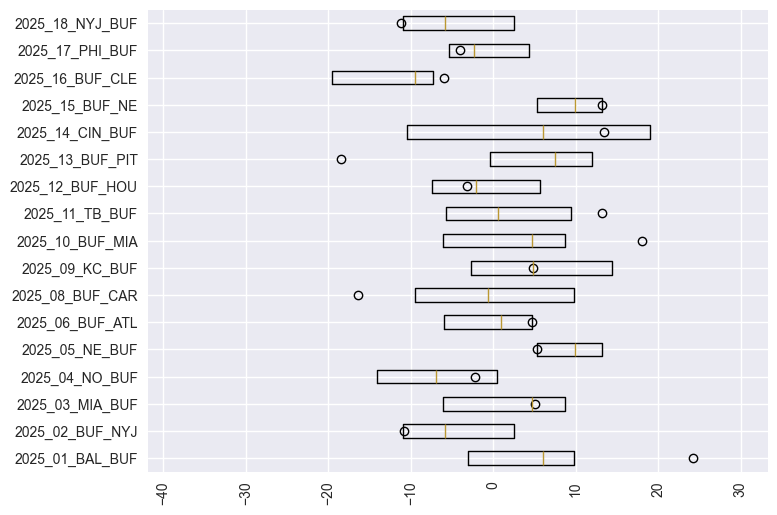

In [116]:
fg,ax = plt.subplots(figsize=(8,6))


bx_buf = bxplot_data_defense(epa_games[epa_games['team']=='BUF'].sort_values(by='game_id'))
ax.bxp(bx_buf[0]
        ,vert=False
        ,showcaps=False # removes the endlines on the whiskers
        ,whiskerprops={'visible': False,}) #removes the whiskers

ax.set_xticklabels(ax.get_xticklabels(), rotation=90,)
# ax.hlines(epa_games.offense_epa.quantile(0.33),0,17,color='red',linestyle='--')
# ax.hlines(epa_games.offense_epa.quantile(0.5),0,17,color='lightgray',linestyle='--')
# ax.hlines(epa_games.offense_epa.quantile(0.66),0,17,color='green',linestyle='--')



In [39]:
buf[['defense_epa','game_id']]

,defense_epa,game_id
30,-24.160796,2025_01_BAL_BUF
362,10.875205,2025_02_BUF_NYJ
287,-5.093064,2025_03_MIA_BUF
332,2.219213,2025_04_NO_BUF
317,-5.298413,2025_05_NE_BUF
16,-4.644943,2025_06_BUF_ATL
63,16.411144,2025_08_BUF_CAR
226,-4.865750,2025_09_KC_BUF
288,-18.010977,2025_10_BUF_MIA
438,-13.196517,2025_11_TB_BUF
